# Dropout Prevention - Train
This notebook loads the processed dropout dataset, prepares the training split, balances the training data with SMOTE, trains the XGBoost model, and saves the model artifacts.

## Import Libraries

In [27]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import joblib

## Load the Processed Dataset

In [28]:
df = pd.read_csv('..\data\processed\dropout_preprocessed.csv')
print('Processed dataset shape:', df.shape)
display(df.head())

Processed dataset shape: (32593, 19)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,total_clicks,active_days,avg_clicks_per_day,relative_engagement,avg_score,avg_lateness
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,487.0,13.0,6.087500,-0.208436,78.0,-1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,625.0,22.0,3.787879,0.042672,70.0,3.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,281.0,12.0,3.697368,-0.583277,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,673.0,31.0,3.416244,0.130013,72.0,-2.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,601.0,26.0,3.828025,-0.000999,69.0,7.0


## Select Features and Split the Data

In [29]:
features = [
    'total_clicks',
    'active_days',
    'relative_engagement',
    'avg_score',
    'avg_lateness',
    'num_of_prev_attempts',
    'studied_credits'
]

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (26074, 7)
Test shape: (6519, 7)


## Visualize Outcome Distribution and Feature Correlation

C:\Users\asus\AppData\Local\Temp\ipykernel_19744\2326884602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='viridis', ax=ax[0])


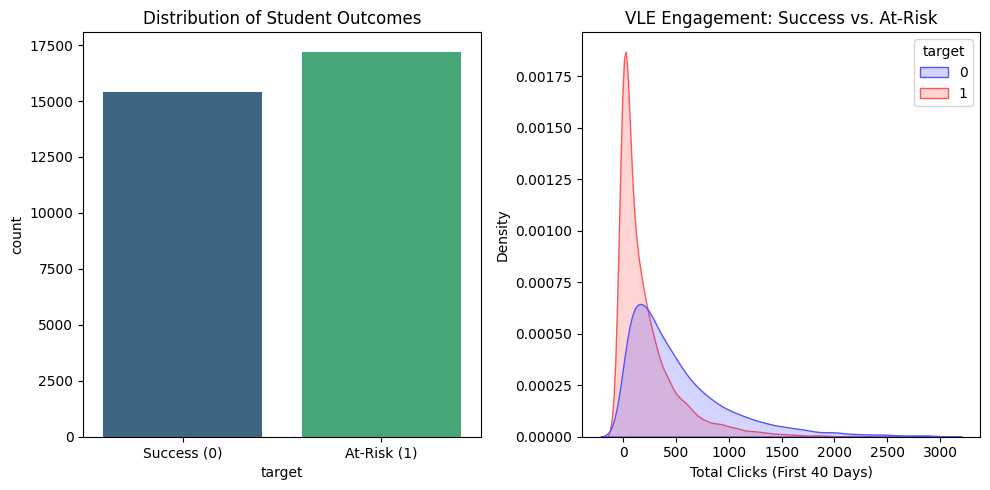

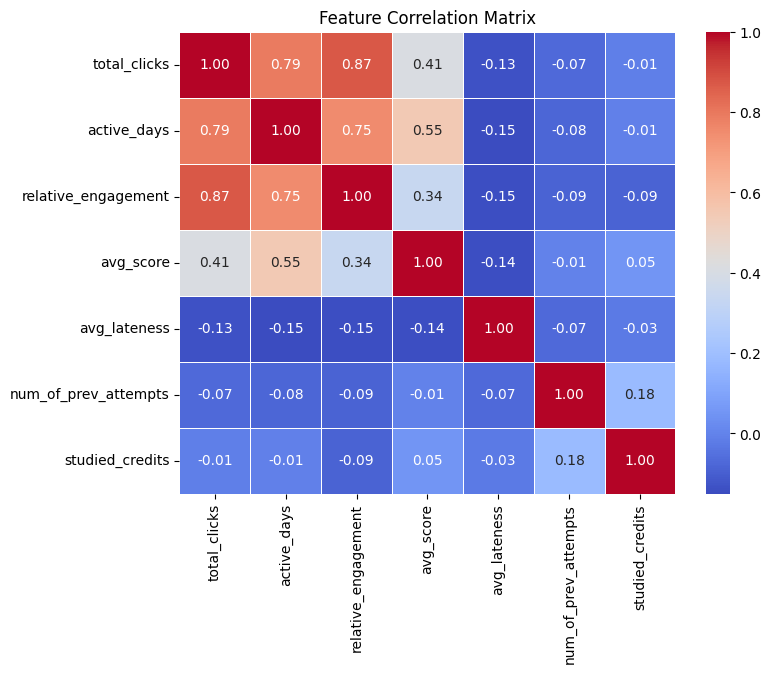

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(data=df, x='target', palette='viridis', ax=ax[0])
ax[0].set_title('Distribution of Student Outcomes')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Success (0)', 'At-Risk (1)'])

sns.kdeplot(data=df[df['total_clicks'] < 3000], x='total_clicks', hue='target', fill=True, ax=ax[1], palette='seismic')
ax[1].set_title('VLE Engagement: Success vs. At-Risk')
ax[1].set_xlabel('Total Clicks (First 40 Days)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## Balance the Training Data with SMOTE

In [31]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('Training set size before SMOTE:', len(y_train))
print('Training set size after SMOTE:', len(y_train_balanced))

Training set size before SMOTE: 26074
Training set size after SMOTE: 27532


## Train the XGBoost Classifier

In [32]:
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=3
)

print("Model Training Completed.")
model.fit(X_train_balanced, y_train_balanced)

Model Training Completed.


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Save Model Artifacts

In [33]:
joblib.dump(model, '..\models\oula_ews_model.pkl')
joblib.dump(features, '..\models\model_features.pkl')

print('Saved model to ..\models\oula_ews_model.pkl')
print('Saved features to ..\models\model_features.pkl')


Saved model to ..\models\oula_ews_model.pkl
Saved features to ..\models\model_features.pkl
